In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
# Load the CSV file containing labels
csv_path = 'KAGGEL DATASET/english.csv'
df = pd.read_csv(csv_path)

# Image directory
image_dir = 'KAGGEL DATASET/'

In [5]:
images = []
labels = []

for index, row in df.iterrows():
    img_path = os.path.join(image_dir, row['image'])
    try:
      img = Image.open(img_path).convert('L') # Open and convert to grayscale
      img = img.resize((28, 28)) # Resize to 28x28
      img_array = np.array(img) / 255.0 # Convert to NumPy array and normalize
      images.append(img_array)
      labels.append(row['label'])
    except FileNotFoundError:
      print(f"Image not found: {img_path}")

X = np.array(images)
y = np.array(labels)

In [6]:
from sklearn.preprocessing import LabelEncoder

# Encode labels to numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# One-hot encode the numerical labels
y_one_hot = tf.keras.utils.to_categorical(y_encoded)

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y_one_hot, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Reshape images for CNN
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_val = X_val.reshape(X_val.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

In [15]:
# Data Augmentation:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)
datagen.fit(X_train)

In [16]:
# More Complex Model:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(y_one_hot[0]), activation='softmax')
])

c:\Users\princ\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Learning Rate Reduction:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)

In [18]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(datagen.flow(X_train, y_train, batch_size=32),
          epochs=20,
          validation_data=(X_val, y_val),
          callbacks=[reduce_lr])

Epoch 1/20


c:\Users\princ\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.0239 - loss: 5.1575 - val_accuracy: 0.0176 - val_loss: 4.1985 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0539 - loss: 4.0536 - val_accuracy: 0.0137 - val_loss: 4.4765 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0801 - loss: 3.8499 - val_accuracy: 0.0176 - val_loss: 4.6200 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1112 - loss: 3.6222 - val_accuracy: 0.0215 - val_loss: 4.5005 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1816 - loss: 3.2505 - val_accuracy: 0.0313 - val_loss: 4.1241 - learning_rate: 2.0000e-04
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1786 - loss: 3.1906 - val_accuracy: 0.0881 - val_loss: 3.6913 - learning_rate: 2.0000e-04
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2209 - loss: 3.0279 - val_accura

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6195 - loss: 1.3481
Test accuracy: 0.642578125


In [20]:
predictions = model.predict(X_test[:5]) #Predict the first 5 test images.
predicted_labels = np.argmax(predictions, axis=1)
original_labels = np.argmax(y_test[:5], axis=1)

print("Predicted Labels:", label_encoder.inverse_transform(predicted_labels))
print("Original Labels:", label_encoder.inverse_transform(original_labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Predicted Labels: ['n' '9' 'u' '5' 'K']
Original Labels: ['n' '9' 'u' 'J' 'K']


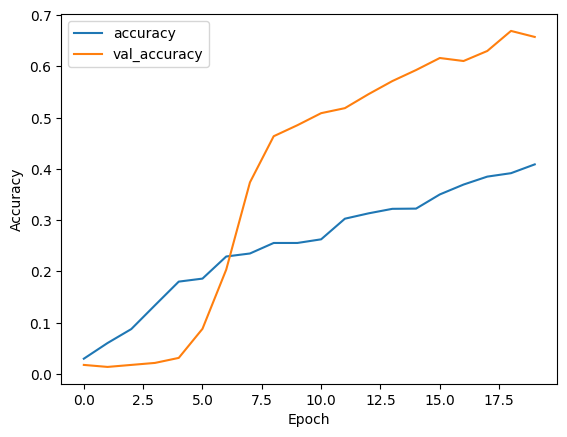

In [21]:
# (Your existing visualization code)
history = model.history.history
plt.plot(history['accuracy'], label='accuracy')
plt.plot(history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ... (rest of the visualization code)

In [22]:
model.save('handwriting_recognition_model.h5')